In [ ]:
import os
print(os.listdir('/kaggle/input'))

['competitions']


In [ ]:
print(os.listdir('/kaggle/input/competitions'))

['airbus-ship-detection']


In [3]:
print(os.listdir('/kaggle/input/competitions/airbus-ship-detection'))

['test_v2', 'sample_submission_v2.csv', 'train_ship_segmentations_v2.csv', 'train_v2']


In [4]:
import pandas as pd
import numpy as np
import cv2
import os
from tqdm import tqdm

# --- Configuration ---
DATASET_DIR = '/kaggle/input/competitions/airbus-ship-detection'
IMAGES_DIR = os.path.join(DATASET_DIR, 'train_v2')
CSV_PATH = os.path.join(DATASET_DIR, 'train_ship_segmentations_v2.csv')

OUTPUT_DIR = '/kaggle/working/dataset'
IMG_SIZE = 768
N_SAMPLES = 3000  # sous-ensemble pour aller vite (ajustable)

os.makedirs(f'{OUTPUT_DIR}/images/train', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/images/val', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/labels/train', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/labels/val', exist_ok=True)

# --- Décodage RLE -> masque binaire ---
def rle_decode(mask_rle, shape=(768, 768)):
    if pd.isna(mask_rle):
        return np.zeros(shape, dtype=np.uint8)
    s = mask_rle.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape).T  # attention : format Fortran (colonnes) dans ce dataset

# --- Masque -> bounding boxes YOLO ---
def mask_to_yolo_boxes(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w < 2 or h < 2:  # ignorer le bruit
            continue
        x_center = (x + w / 2) / IMG_SIZE
        y_center = (y + h / 2) / IMG_SIZE
        w_norm = w / IMG_SIZE
        h_norm = h / IMG_SIZE
        boxes.append((0, x_center, y_center, w_norm, h_norm))  # classe 0 = ship
    return boxes

# --- Charger le CSV et regrouper par image ---
df = pd.read_csv(CSV_PATH)
grouped = df.groupby('ImageId')['EncodedPixels'].apply(list).reset_index()

# Prendre un sous-ensemble équilibré : moitié avec navires, moitié sans
with_ships = grouped[grouped['EncodedPixels'].apply(lambda x: not all(pd.isna(v) for v in x))]
without_ships = grouped[grouped['EncodedPixels'].apply(lambda x: all(pd.isna(v) for v in x))]

n_each = N_SAMPLES // 2
subset = pd.concat([
    with_ships.sample(min(n_each, len(with_ships)), random_state=42),
    without_ships.sample(min(n_each, len(without_ships)), random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)  # mélanger

# Split train/val (80/20)
split_idx = int(len(subset) * 0.8)
train_ids = subset[:split_idx]
val_ids = subset[split_idx:]

def process_split(ids_df, split_name):
    for _, row in tqdm(ids_df.iterrows(), total=len(ids_df), desc=split_name):
        image_id = row['ImageId']
        src_img_path = os.path.join(IMAGES_DIR, image_id)
        if not os.path.exists(src_img_path):
            continue

        # Copier l'image
        dst_img_path = f'{OUTPUT_DIR}/images/{split_name}/{image_id}'
        img = cv2.imread(src_img_path)
        cv2.imwrite(dst_img_path, img)

        # Construire le masque combiné (plusieurs navires possibles)
        combined_mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        for rle in row['EncodedPixels']:
            if pd.notna(rle):
                combined_mask |= rle_decode(rle)

        boxes = mask_to_yolo_boxes(combined_mask)

        # Écrire le fichier .txt (vide si aucun navire = image négative, valide pour YOLO)
        label_path = f'{OUTPUT_DIR}/labels/{split_name}/{os.path.splitext(image_id)[0]}.txt'
        with open(label_path, 'w') as f:
            for cls, xc, yc, w, h in boxes:
                f.write(f'{cls} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n')

process_split(train_ids, 'train')
process_split(val_ids, 'val')

print(f"Terminé : {len(train_ids)} images train, {len(val_ids)} images val")

val: 100%|██████████| 600/600 [00:09<00:00, 63.44it/s]

Terminé : 2400 images train, 600 images val


In [5]:
yaml_content = """
path: /kaggle/working/dataset
train: images/train
val: images/val
names:
  0: ship
"""
with open('/kaggle/working/ships.yaml', 'w') as f:
    f.write(yaml_content)

print("Fichier ships.yaml créé")


Fichier ships.yaml créé


In [6]:
!pip install ultralytics -q
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='/kaggle/working/ships.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,          # force l'utilisation du GPU
    name='ship_detector',
    patience=10         # arrête plus tôt si pas d'amélioration
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 715.4 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 7.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 7.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.157 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/ships.yaml, degrees=0.

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/30      2.48G      1.878      2.775      1.263         23        640: 100% ━━━━━━━━━━━━ 150/150 7.6it/s 19.6s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 6.3it/s 3.0s0.2s
                   all        600        497      0.367      0.171      0.166     0.0855

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/30      2.48G      1.949      2.159      1.329         20        640: 100% ━━━━━━━━━━━━ 150/150 7.6it/s 19.9s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 6.7it/s 2.8s0.1s
                   all        600        497      0.454      0.296      0.313      0.157

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/30      2.48G      1.895      1.875      1.316         36        640: 100% ━━━━━━━━━━━━ 150/150 7.7it/s 19.6s0.1s
                 Class     Images

In [7]:
import os
print(os.path.exists('/kaggle/working/runs/detect/ship_detector/weights/best.pt'))

True


In [8]:
model = YOLO('/kaggle/working/runs/detect/ship_detector/weights/best.pt')
metrics = model.val()
print(f"mAP50: {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Précision: {metrics.box.mp:.3f}")
print(f"Rappel: {metrics.box.mr:.3f}")


Ultralytics 8.4.157 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2448.5±892.2 MB/s, size: 94.3 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 600 images, 305 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 600/600 251.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 7.4it/s 5.1s0.1s
                   all        600        497      0.733      0.606      0.686      0.415
Speed: 1.4ms preprocess, 3.8ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP50: 0.686
mAP50-95: 0.415
Précision: 0.733
Rappel: 0.606


In [11]:
import os

val_dir = '/kaggle/working/dataset/images/val'
val_images = os.listdir(val_dir)

found = False
for img_name in val_images:
    results = model.predict(f'{val_dir}/{img_name}', conf=0.5, verbose=False)
    if len(results[0].boxes) > 0:
        print(f"Détection trouvée : {img_name} — {len(results[0].boxes)} navire(s)")
        results[0].save(filename='/kaggle/working/detection_example.jpg')
        found = True
        break

if not found:
    print("Aucune détection trouvée avec conf=0.5, réessayez avec conf=0.25")

Détection trouvée : a275b9660.jpg — 1 navire(s)


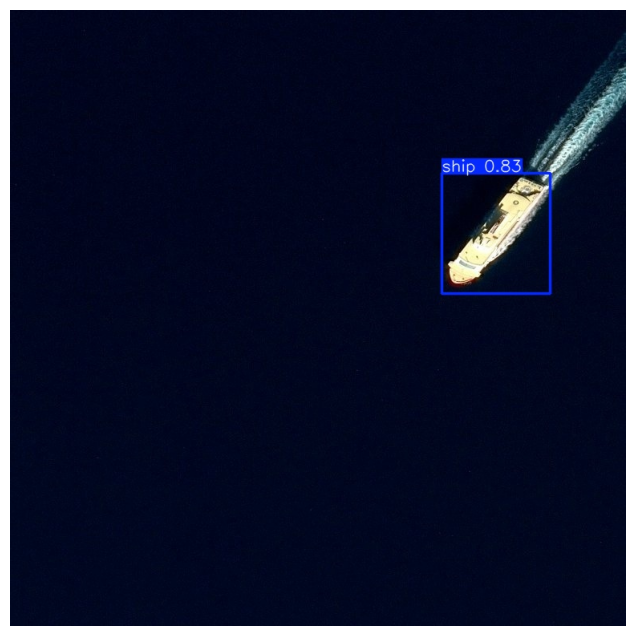

In [12]:
import matplotlib.pyplot as plt
img = plt.imread('/kaggle/working/detection_example.jpg')
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis('off')
plt.show()

In [13]:
from IPython.display import FileLink
FileLink('/kaggle/working/runs/detect/ship_detector/weights/best.pt')

/kaggle/working/runs/detect/ship_detector/weights/best.pt

In [14]:
import shutil
shutil.copy('/kaggle/working/runs/detect/ship_detector/weights/best.pt', '/kaggle/working/best.pt')

from IPython.display import FileLink
FileLink('best.pt')

/kaggle/working/best.pt

In [16]:
from ultralytics import YOLO
model = YOLO('detection/models/best.pt')  # ça, ça marche

FileNotFoundError: [Errno 2] No such file or directory: 'detection/models/best.pt'